## 1. Configuración del entorno



In [2]:
# ==========================================
# Etapa 1: Recolección y Carga de Datos
# ==========================================
import pandas as pd
from pathlib import Path

# Buscamos el archivo results.csv en la carpeta local
DATA_PATH = Path('data/results.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../data/results.csv') # Alternativa si estás dentro de una subcarpeta como 'notebooks'

df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print(f"Dataset cargado exitosamente — Registros: {len(df):,} | Columnas: {df.shape[1]}")
df.head()

Dataset cargado exitosamente — Registros: 49,547 | Columnas: 9


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


---
## 3. Etapa 2 — Exploración y preparación de datos
Analizamos la estructura interna del dataset, revisamos si existen valores nulos o duplicados, y transformamos los goles en nuestra variable objetivo (`resultado`), asegurando **excluir los goles** de las entradas para evitar la fuga de datos (*data leakage*).

In [5]:
# ==========================================
# 3. Etapa 2 — Exploración y preparación de datos (EDA)
# ==========================================
import numpy as np  # <-- Asegúrate de tener esto importado aquí si no corriste la primera celda

print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
df.info()
print('\n')
display(df.describe().round(2))

# Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Limpieza y orden cronológico estricto
df = df.drop_duplicates().dropna(subset=['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral']).copy()
df = df.sort_values('date').reset_index(drop=True)

# Creación de la variable objetivo (resultado del partido)
df['resultado'] = np.select(
    [
        df['home_score'] > df['away_score'],
        df['home_score'] < df['away_score']
    ],
    [
        'gana_local',
        'gana_visita'
    ],
    default='empate'
)

# Variables de tiempo auxiliares
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print(f'\nRegistros después de limpieza: {df.shape[0]:,}')
print('Distribución de la variable objetivo:\n', df['resultado'].value_counts())

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 49547 entries, 0 to 49546
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49547 non-null  datetime64[us]
 1   home_team   49547 non-null  str           
 2   away_team   49547 non-null  str           
 3   home_score  49547 non-null  int64         
 4   away_score  49547 non-null  int64         
 5   tournament  49547 non-null  str           
 6   city        49547 non-null  str           
 7   country     49547 non-null  str           
 8   neutral     49547 non-null  bool          
dtypes: bool(1), datetime64[us](1), int64(2), str(5)
memory usage: 3.1 MB




,date,home_score,away_score
count,49547,49547.00,49547.00
mean,1994-06-07 16:43:07.216178,1.76,1.18
min,1872-11-30 00:00:00,0.00,0.00
25%,1980-09-18 00:00:00,1.00,0.00
50%,2000-07-28 00:00:00,1.00,1.00
75%,2013-08-14 00:00:00,2.00,2.00
max,2026-08-26 00:00:00,31.00,21.00
std,NaN,1.77,1.40


Valores nulos por columna:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Registros duplicados: 0

Registros después de limpieza: 49,547
Distribución de la variable objetivo:
 resultado
gana_local     24276
gana_visita    14010
empate         11261
Name: count, dtype: int64


---
---
## 3. Etapa 2 — Exploración y preparación de datos
Analizamos la estructura general del dataset de fútbol, verificamos valores nulos y duplicados, y definimos la variable objetivo (`resultado`) a partir de los goles, asegurando **excluir los marcadores reales** para evitar la fuga de datos (*data leakage*).

In [9]:
# ==========================================
# 3. Etapa 2 — Exploración y preparación de datos
# ==========================================
print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
df.info()
print('\n')
display(df.describe().round(2))

# Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

# Limpieza y orden cronológico estricto
df = df.drop_duplicates().dropna(subset=['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral']).copy()
df = df.sort_values('date').reset_index(drop=True)

# Creación de la variable objetivo (resultado del partido) evitando data leakage
df['resultado'] = np.select(
    [
        df['home_score'] > df['away_score'],
        df['home_score'] < df['away_score']
    ],
    [
        'gana_local',
        'gana_visita'
    ],
    default='empate'
)

# Variables de tiempo auxiliares
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print(f'\nRegistros después de limpieza: {df.shape[0]:,}')
print('Distribución de la variable objetivo:\n', df['resultado'].value_counts())

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 49547 entries, 0 to 49546
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49547 non-null  datetime64[us]
 1   home_team   49547 non-null  str           
 2   away_team   49547 non-null  str           
 3   home_score  49547 non-null  int64         
 4   away_score  49547 non-null  int64         
 5   tournament  49547 non-null  str           
 6   city        49547 non-null  str           
 7   country     49547 non-null  str           
 8   neutral     49547 non-null  bool          
 9   resultado   49547 non-null  str           
 10  year        49547 non-null  int32         
 11  month       49547 non-null  int32         
dtypes: bool(1), datetime64[us](1), int32(2), int64(2), str(6)
memory usage: 3.8 MB




,date,home_score,away_score,year,month
count,49547,49547.00,49547.00,49547.00,49547.00
mean,1994-06-07 16:43:07.216178,1.76,1.18,1993.90,6.90
min,1872-11-30 00:00:00,0.00,0.00,1872.00,1.00
25%,1980-09-18 00:00:00,1.00,0.00,1980.00,4.00
50%,2000-07-28 00:00:00,1.00,1.00,2000.00,7.00
75%,2013-08-14 00:00:00,2.00,2.00,2013.00,10.00
max,2026-08-26 00:00:00,31.00,21.00,2026.00,12.00
std,NaN,1.77,1.40,25.45,3.23


Valores nulos por columna:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
resultado     0
year          0
month         0
dtype: int64

Registros duplicados: 0

Registros después de limpieza: 49,547
Distribución de la variable objetivo:
 resultado
gana_local     24276
gana_visita    14010
empate         11261
Name: count, dtype: int64


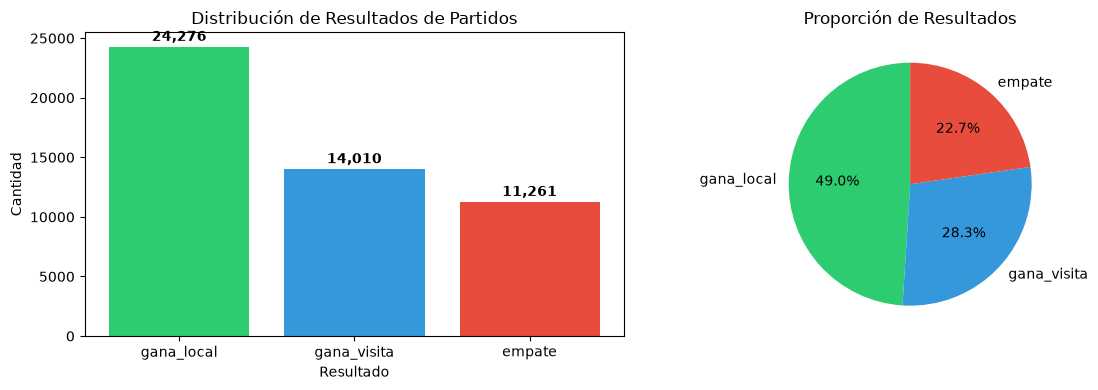

In [13]:
import matplotlib.pyplot as plt

# ==========================================
# Gráfico de distribución de la variable objetivo
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['resultado'].value_counts()
colores = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(target_counts.index, target_counts.values, color=colores[:len(target_counts)])
axes[0].set_title('Distribución de Resultados de Partidos')
axes[0].set_xlabel('Resultado')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    target_counts.values, labels=target_counts.index,
    autopct='%1.1f%%', colors=colores[:len(target_counts)], startangle=90
)
axes[1].set_title('Proporción de Resultados')

plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos y Partición Cronológica
Seleccionamos las características de entrada ($X$) y la variable objetivo ($y$). **Nota de Ingeniería:** Excluimos intencionalmente `home_score` y `away_score` para prevenir la fuga de datos (*data leakage*). Además, aplicamos una partición cronológica estricta (`shuffle=False`) para entrenar con el pasado y predecir el futuro.

In [15]:
from sklearn.model_selection import train_test_split

# ==========================================
# Etapa 3: Preparación de Datos y Partición Cronológica
# ==========================================
features = ['home_team', 'away_team', 'tournament', 'neutral', 'year', 'month']
X = df[features]
y = df['resultado']

# Partición cronológica estricta (shuffle=False para respetar la línea del tiempo)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

print(f'Entrenamiento (Pasado): {X_train.shape[0]:,} muestras')
print(f'Prueba (Futuro): {X_test.shape[0]:,} muestras')

Entrenamiento (Pasado): 39,637 muestras
Prueba (Futuro): 9,910 muestras


---
## 5. Etapa 4 — Entrenamiento de modelos y Pipeline
Construimos un pipeline de Scikit-learn que procesa de forma automatizada las variables categóricas (usando `OneHotEncoder`) y las numéricas (usando `StandardScaler`), conectándolas directamente a nuestro modelo de **Regresión Logística**.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ==========================================
# Etapa 4: Pipeline y Entrenamiento
# ==========================================
categorical_features = ['home_team', 'away_team', 'tournament', 'neutral']
numeric_features = ['year', 'month']

preprocesador = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

modelo_futbol = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('clasificador', LogisticRegression(max_iter=2000, n_jobs=1))
])

print('Entrenando el modelo con los datos del pasado...')
modelo_futbol.fit(X_train, y_train)
print('¡Modelo entrenado con éxito!')

Entrenando el modelo con los datos del pasado...


c:\Users\LOQ\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


¡Modelo entrenado con éxito!


---
## 6. Etapa 5 y 6 — Evaluación, Serialización y Predicción en Vivo
Evaluamos el rendimiento del modelo utilizando el conjunto de prueba cronológico futuro, generamos la matriz de confusión multiclase, serializamos el modelo entrenado con `joblib` y realizamos una prueba de predicción en vivo.


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      empate       0.31      0.11      0.16      2307
  gana_local       0.60      0.83      0.70      4715
 gana_visita       0.56      0.50      0.53      2888

    accuracy                           0.57      9910
   macro avg       0.49      0.48      0.46      9910
weighted avg       0.52      0.57      0.52      9910



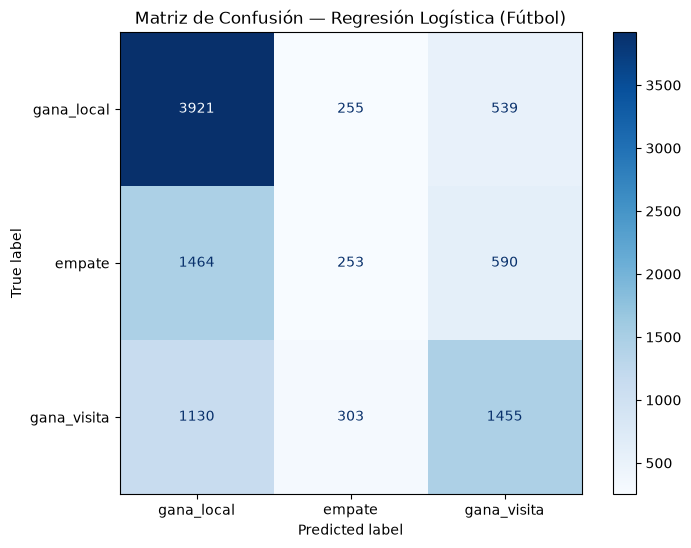


¡Modelo guardado en disco como "modelo_futbol.pkl"!

--- PRUEBA DE PREDICCIÓN EN VIVO ---
Encuentro: Peru vs Denmark
Predicción del modelo: GANA_VISITA
Probabilidades calculadas:
 - empate: 23.1%
 - gana_local: 28.2%
 - gana_visita: 48.7%


In [17]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# ==========================================
# Etapa 5 y 6: Evaluación y Serialización
# ==========================================
y_pred = modelo_futbol.predict(X_test)

print('\n--- REPORTE DE CLASIFICACIÓN ---')
print(classification_report(y_test, y_pred))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, cmap='Blues',
    labels=['gana_local', 'empate', 'gana_visita']
)
plt.title('Matriz de Confusión — Regresión Logística (Fútbol)')
plt.grid(False)
plt.show()

# Serialización del modelo entrenado
ruta_modelo = 'modelo_futbol.pkl'
joblib.dump(modelo_futbol, ruta_modelo)
print(f'\n¡Modelo guardado en disco como "{ruta_modelo}"!')

# Prueba de predicción en vivo
partido_ficticio = pd.DataFrame([{
    'home_team': 'Peru',
    'away_team': 'Denmark',
    'tournament': 'FIFA World Cup',
    'neutral': True,
    'year': 2026,
    'month': 6
}])

prediccion = modelo_futbol.predict(partido_ficticio)[0]
probabilidades = modelo_futbol.predict_proba(partido_ficticio)[0]
clases = modelo_futbol.classes_

print('\n--- PRUEBA DE PREDICCIÓN EN VIVO ---')
print(f"Encuentro: {partido_ficticio['home_team'].iloc[0]} vs {partido_ficticio['away_team'].iloc[0]}")
print(f"Predicción del modelo: {prediccion.upper()}")
print('Probabilidades calculadas:')
for clase, prob in zip(clases, probabilidades):
    print(f' - {clase}: {prob:.1%}')

---
## 7. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Carga del dataset histórico de partidos internacionales de fútbol | `pandas`, `Path` |
| **Exploración** | Análisis de nulos, duplicados y distribución de clases del target (`resultado`) | `matplotlib`, `seaborn`, `numpy` |
| **Preparación** | Limpieza de datos, variables de tiempo y partición cronológica estricta | `train_test_split` (`shuffle=False`) |
| **Entrenamiento** | Construcción de pipeline automatizado para preprocesamiento y clasificación multiclase | `Pipeline`, `ColumnTransformer`, `LogisticRegression` |
| **Evaluación** | Análisis del reporte de clasificación y generación de la matriz de confusión | `classification_report`, `ConfusionMatrixDisplay` |
| **Despiegue** | Serialización del modelo entrenado y prueba de predicción en vivo | `joblib`, `pandas` |

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*